In [2]:
import pandas as pd 
import matplotlib
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.1f}'.format


In [5]:
def remove_outliers(dataset, groupby, var_to_compute):
      
        grouped = dataset.groupby(by=groupby)[var_to_compute]

        q1 = grouped.transform('quantile' , 0.25)
        q3 = grouped.transform('quantile' , 0.75)

        iqr = q3 - q1 

        lower_bound  = q1 - 1,5 * iqr 
        upper_bound = q3 + 1,5 * iqr 

        mask = ( ( dataset[var_to_compute] <= lower_bound ) & ( dataset[var_to_compute] >= upper_bound )  )

        return dataset[mask]

In [6]:

def stats( dataset , groupby: str , var_to_compute : str ,  statistics=None):
    
    if statistics == None :
        statistics = ['count' , 'min' , 'max' , 'median' , 'mean' , 'std']
    
    statis_data = dataset.groupby(groupby)[var_to_compute].agg(
        statistics
    )
    statis_data['cv'] = statis_data['std'] / statis_data['mean']
    statis_data['cv_%'] = statis_data['std'] / statis_data['mean'] * 100
    
    return statis_data


In [28]:
def scaling():
    pass

In [7]:
df = pd.read_csv("result.csv")


### Check the Outliers

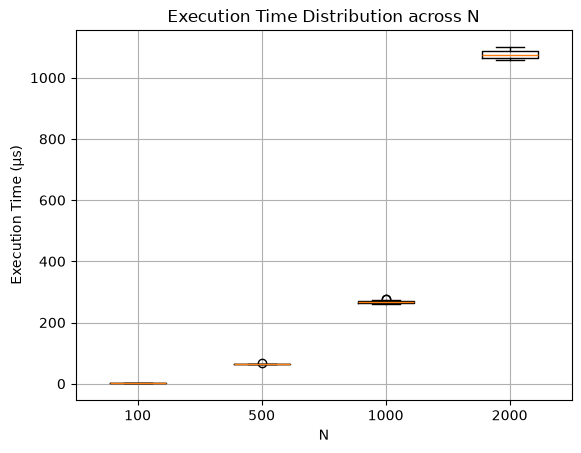

In [9]:
plt.boxplot([df[df['N'] == n]['time_us'] for n in [100, 500, 1000, 2000]], 
            tick_labels=[100, 500, 1000, 2000],
            )
plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("Execution Time Distribution across N")
plt.grid(True)
plt.show()

### Remove the Outliers Using IQR :

In [82]:

groupby = "N"
var_to_compute = "time_us" 
intervalle = 3

clean_data = remove_outliers(df , groupby , var_to_compute )


print(f"Original Samples : {len(df)}" )
print(f"Clean Samples : {len(clean_data)}")

removed_percentages = ( len(df) - len(clean_data)  )/ len(clean_data) * 100

print(f"Removed         : {removed_percentages:.2f} %")

Original Samples : 80
Clean Samples : 77
Removed         : 3.90 %


In [ ]:
original_count = df.groupby('N').size()
clean_count = clean_data.groupby('N').size()

outlier_stats = pd.DataFrame({
    'original': original_count,
    'clean': clean_count
})

outlier_stats['removed'] = (
    outlier_stats['original'] -
    outlier_stats['clean']
)

outlier_stats['removed_%'] = (
    outlier_stats['removed'] /
    outlier_stats['original'] * 100
)

outlier_stats


,original,clean,removed,removed_%
N,,,,
100,20,20,0,0.0
500,20,19,1,5.0
1000,20,18,2,10.0
2000,20,20,0,0.0


### Statistics


In [85]:
groupby = "N"
var_to_compute = "time_us" 
stats_data =  stats( clean_data , groupby, var_to_compute)
stats_data

,count,min,max,median,mean,std,cv,cv_%
N,,,,,,,,
100,20,2,2,2.0,2.0,0.0,0.0,0.0
500,19,64,66,64.0,64.4,0.6,0.0,0.9
1000,18,259,273,268.0,266.9,3.6,0.0,1.4
2000,20,1057,1100,1074.5,1076.4,13.2,0.0,1.2


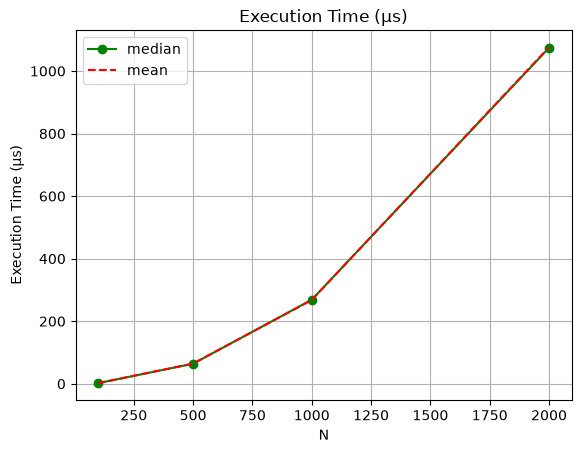

In [ ]:
# median_execution_time():

plt.plot(stats_data['N'], stats_data['median'], color='green', marker='o', label='median')
plt.plot(stats_data['N'], stats_data['mean'], color='red', linestyle='--', label='mean')

plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("Execution Time (µs)")
plt.grid(True)
plt.legend() 
plt.show()

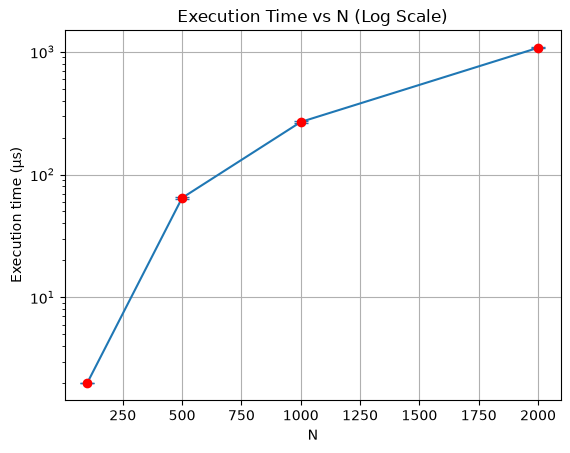

In [52]:
# execution_time_log():
plt.errorbar(
    stats_data['N'],
    stats_data['mean'],
    yerr=stats_data['std'],
    fmt='-',
    capsize=5
)

plt.scatter(
    stats_data['N'],
    stats_data['mean'],
    color='red',
    zorder=3
)

plt.yscale('log')

plt.xlabel("N")
plt.ylabel("Execution time (µs)")
plt.title("Execution Time vs N (Log Scale)")
plt.grid(True)

plt.show()